# Imports

In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from tqdm import tqdm
from pathlib import Path

from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pulse_analysis import read_root_file, format_root_data
from pulse_analysis import find_all_pulses, find_pulse_groups

# Load the data

In [33]:
dac_to_pe = [0.000770, 0.000769]
max_events = 100000

file_str = "260508_1537"
data_dir = Path("/disk/gfs_atp/lhoetz/marmotx/X-detector/data_20260508/" + file_str)
file_name = Path(file_str + "_Module_0_0.root")

full_path = data_dir / file_name
_ar = read_root_file(full_path, max_events=max_events)
data = format_root_data(_ar, n_baseline_samples=50, dac_to_pe=dac_to_pe)

Raw file keys: ['t1;96', 't1;95']
Number of events: 100000
Sample length: 2500


In [ ]:
results = find_all_pulses(
    data,
    hi_sigma=5.0,
    lo_sigma=2.5,
    smooth_window=3,
    max_gap=10,
    pad=5,
    min_width=7,
)

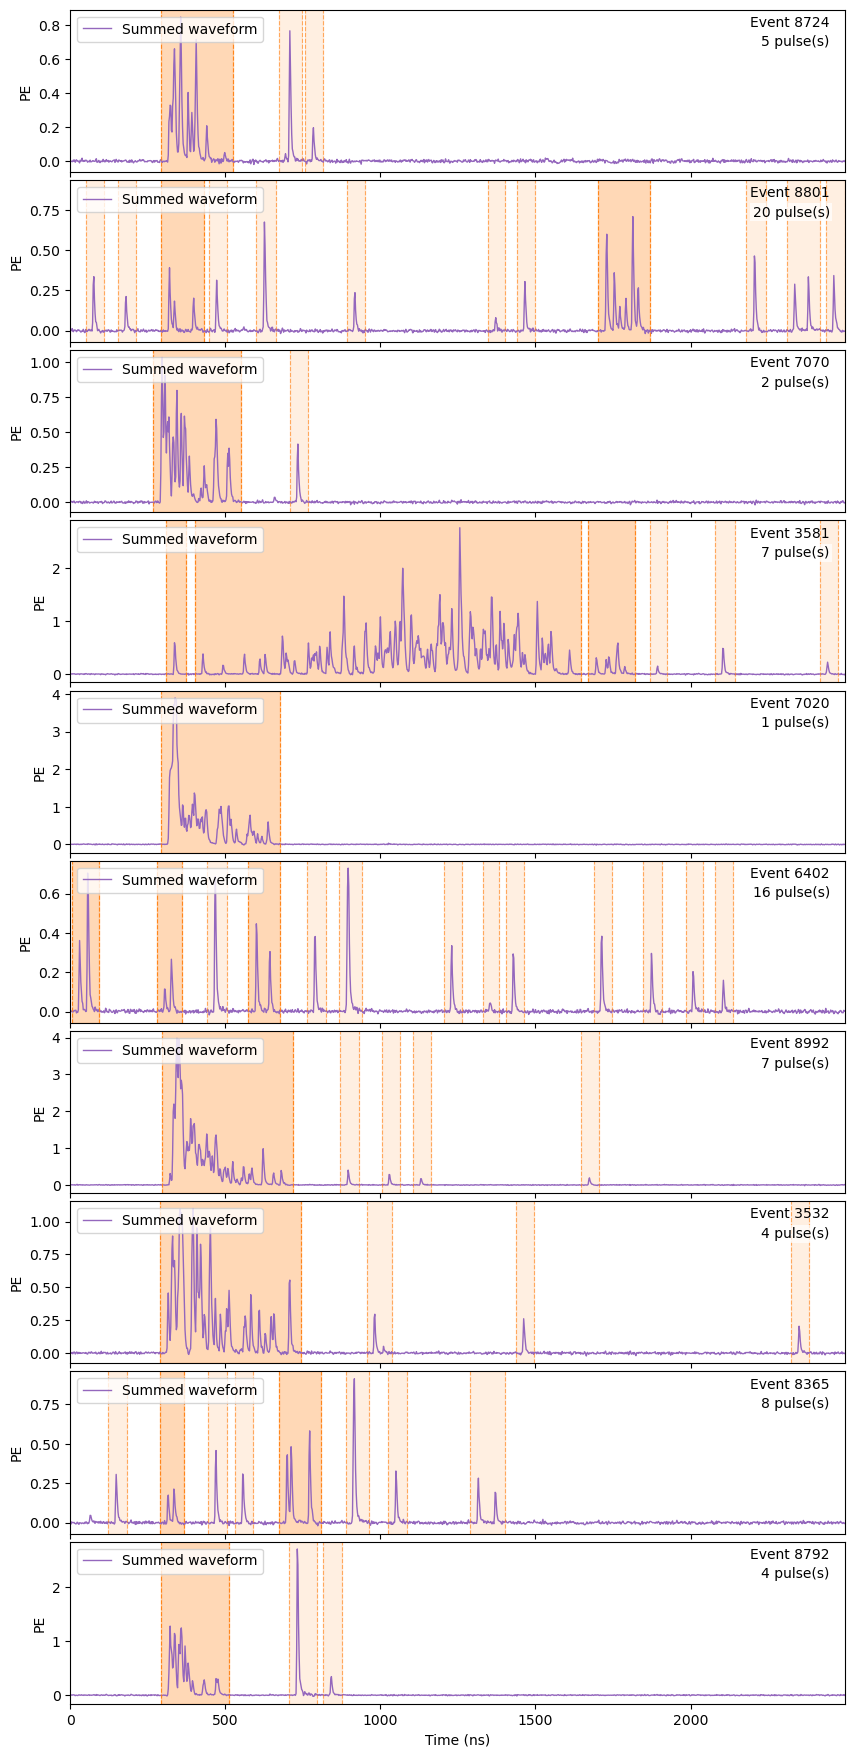

In [ ]:
n_plot = 10
indices = np.random.choice(len(data), size=min(n_plot, len(data)), replace=False)
sP = 2
x_array = np.arange(data["wfs"].shape[2]) * sP  # time in ns

fig, axs = plt.subplots(
    len(indices), 1,
    figsize=(10, 2.2 * len(indices)),
    sharex=True
)

if len(indices) == 1:
    axs = [axs]

for ax, i in zip(axs, indices):
    event_id = data["event_index"][i]

    summed_wf = data["wfs"][i, 0, :] + data["wfs"][i, 1, :]
    pulses, summed, smooth = find_pulse_groups(data[i])

    ax.plot(x_array, summed_wf, color="tab:purple", lw=1, label="Summed waveform")

    for p in pulses:
        # shade differently if pulse is coincident across both channels
        if p.get("two_channel_pulse", False):
            span_alpha = 0.30
            line_alpha = 0.9
        else:
            span_alpha = 0.12
            line_alpha = 0.6

        ax.axvspan(p["start"]*sP, p["end"]*sP, color="tab:orange", alpha=span_alpha)
        ax.axvline(p["start"]*sP, color="tab:orange", ls="--", lw=0.8, alpha=line_alpha)
        ax.axvline(p["end"]*sP, color="tab:orange", ls="--", lw=0.8, alpha=line_alpha)

    ax.text(
        0.98, 0.80,
        f"{len(pulses)} pulse(s)",
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=10,
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5),
    )

    ax.text(
        0.98, 0.92,
        f"Event {event_id}",
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=10,
        color="black",
    )

    ax.set_ylabel("PE")
    ax.set_xlim(0, len(summed_wf) - 1)
    ax.legend(loc="upper left")

axs[-1].set_xlabel("Time (ns)")
plt.subplots_adjust(hspace=0.05)
plt.show()

In [ ]:
all_sums = []
all_widths = []
all_amps = []
is_two_channel = []

for ev in results:

    pulses = ev["pulses"] if ev["pulses"] else None

    if pulses is not None:
        # unpack into the lists
        for p in pulses:
            is_two_channel.append(p["two_channel_pulse"])
            all_sums.append(p["sum"])
            all_widths.append(p["width"])
            all_amps.append(p["peak_amplitude"])


# To nunmpy arrays
all_sums = np.array(all_sums)
all_widths = np.array(all_widths)
all_amps = np.array(all_amps)
is_two_channel = np.array(is_two_channel)

In [ ]:
# # Apply some guessing cuts about widht
# cut_mask = (all_widths < 200) & (all_widths > 25)
# all_sums = all_sums[cut_mask]
# all_widths = all_widths[cut_mask]
# all_amps = all_amps[cut_mask]
# is_two_channel = is_two_channel[cut_mask]

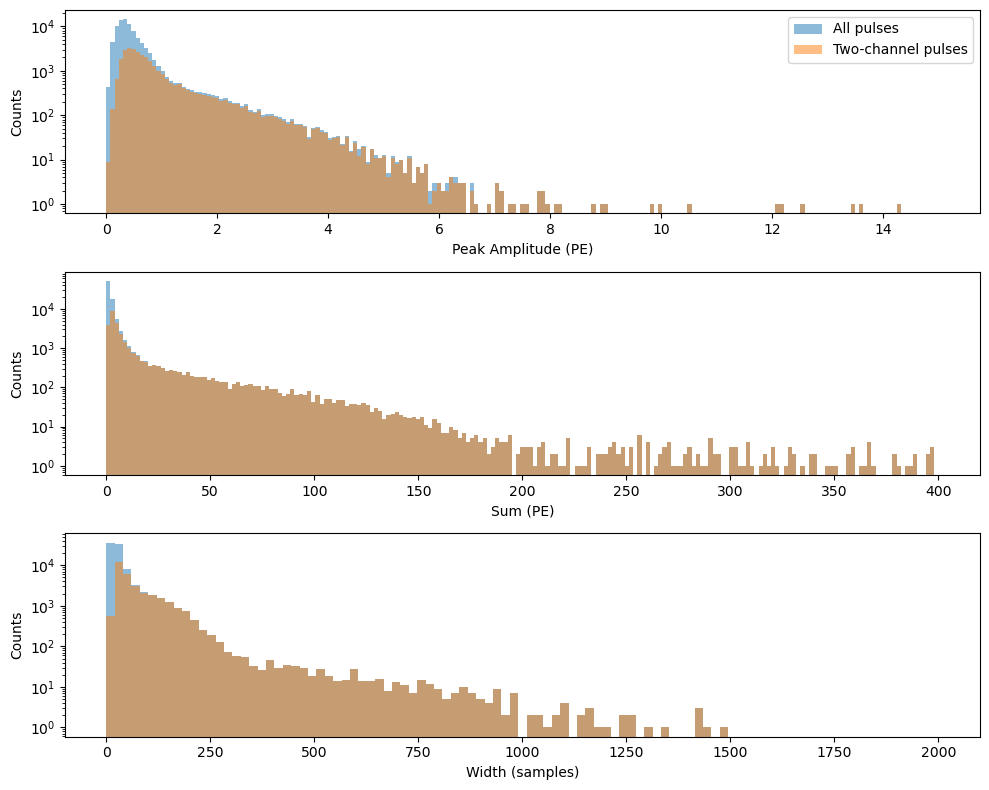

In [ ]:
amp_bins = np.linspace(0, 15, 200)
sums_bins = np.linspace(0, 400, 200)
width_bins = np.linspace(0, 2000, 100)

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=False)
axs[0].hist(all_amps, bins=amp_bins, label="All pulses", alpha=0.5)
axs[0].hist(all_amps[is_two_channel], bins=amp_bins, label="Two-channel pulses", alpha=0.5)
axs[1].hist(all_sums, bins=sums_bins, label="All pulses", alpha=0.5)
axs[1].hist(all_sums[is_two_channel], bins=sums_bins, label="Two-channel pulses", alpha=0.5)
axs[2].hist(all_widths, bins=width_bins, label="All pulses", alpha=0.5)
axs[2].hist(all_widths[is_two_channel], bins=width_bins, label="Two-channel pulses", alpha=0.5)

axs[0].set_xlabel("Peak Amplitude (PE)")
axs[1].set_xlabel("Sum (PE)")
axs[2].set_xlabel("Width (samples)")

axs[0].set_ylabel("Counts")
axs[1].set_ylabel("Counts")
axs[2].set_ylabel("Counts")

axs[0].legend(loc="upper right")

axs[0].set_yscale("log")
axs[1].set_yscale("log")
axs[2].set_yscale("log")

plt.tight_layout()
plt.show()

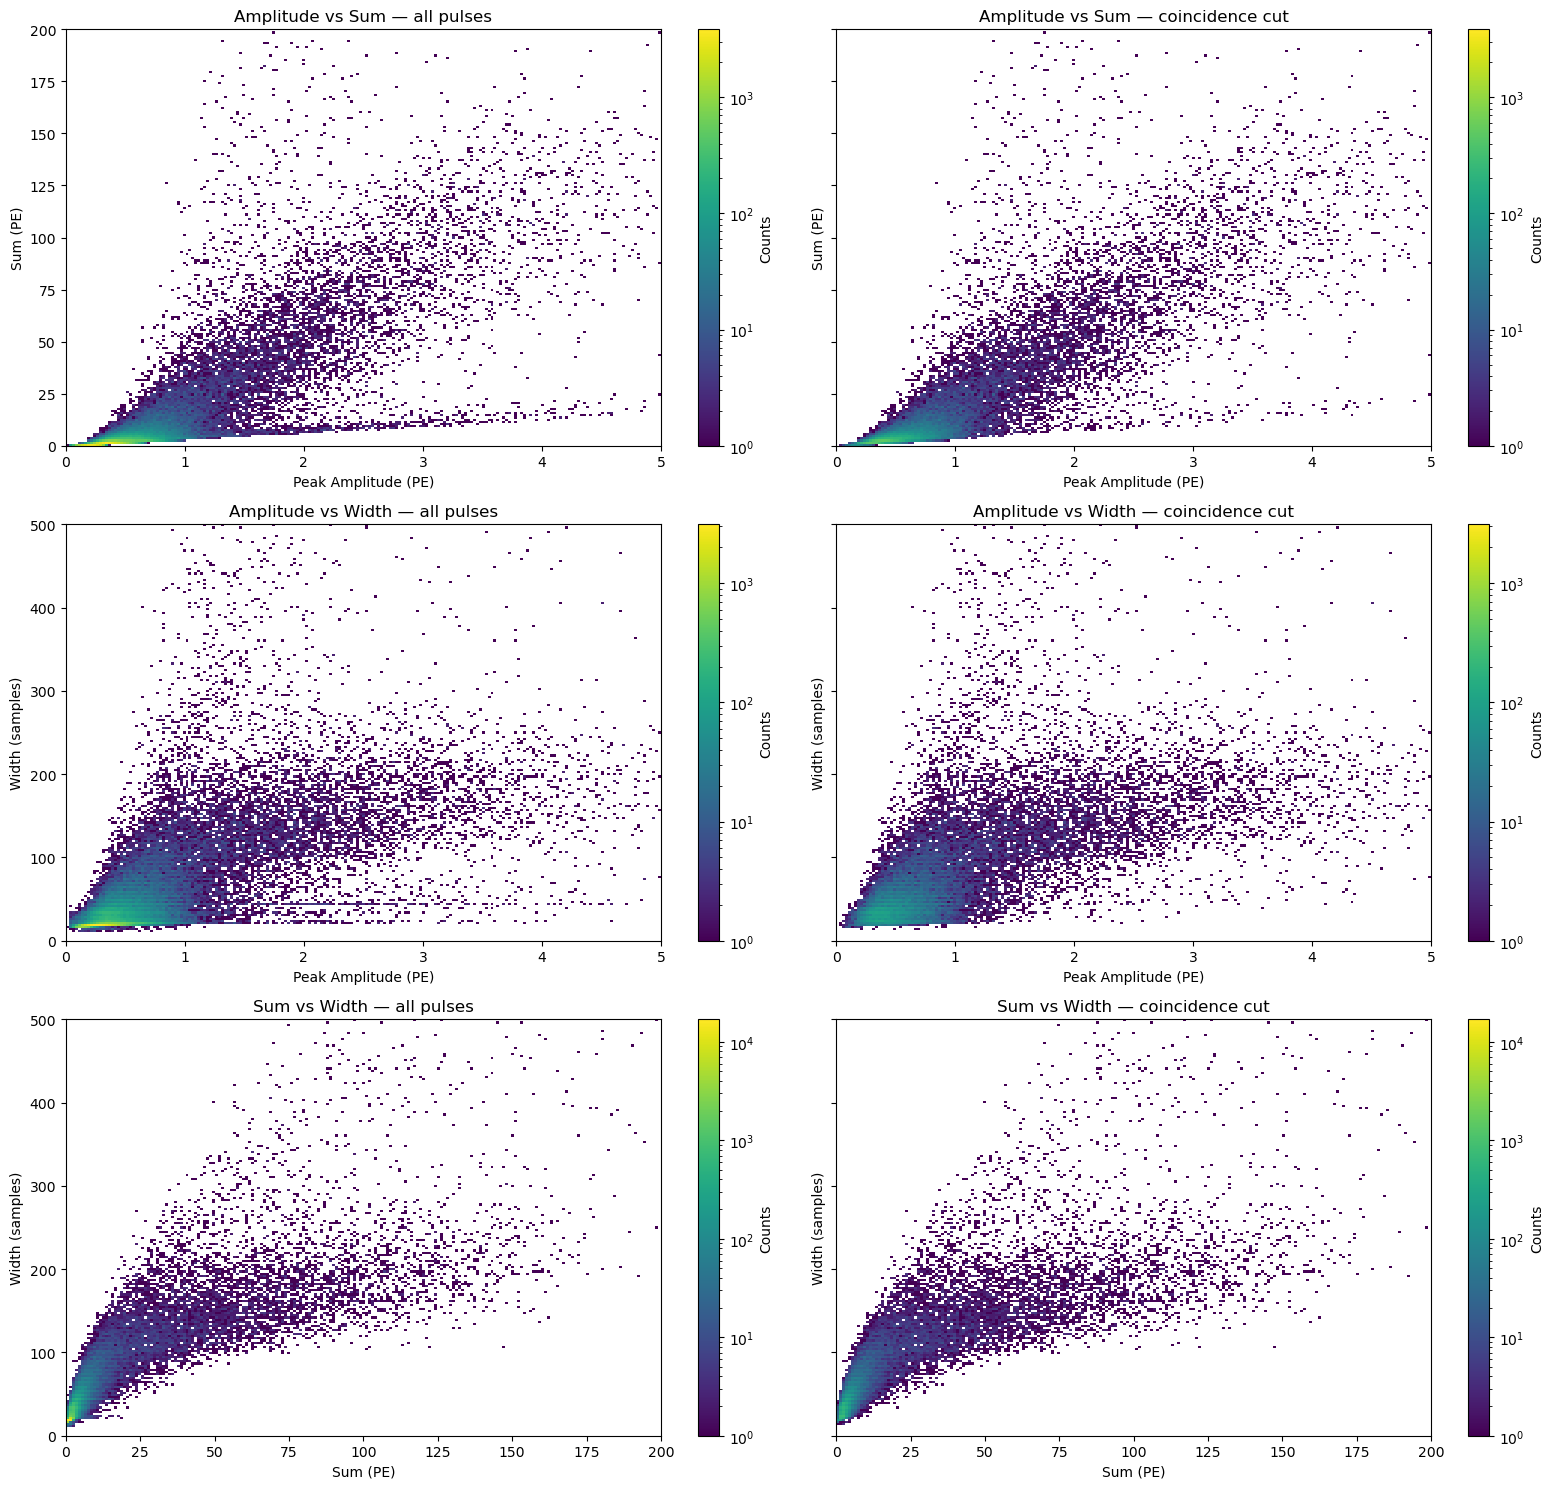

In [ ]:
coinc_mask = is_two_channel.astype(bool)

amp_bins = np.linspace(0, 5, 200)
sums_bins = np.linspace(0, 200, 200)
width_bins = np.linspace(0, 500, 200)

fig, axs = plt.subplots(3, 2, figsize=(16, 15), sharey="row")

rows = [
    (all_amps, all_sums, amp_bins, sums_bins, "Peak Amplitude (PE)", "Sum (PE)", "Amplitude vs Sum"),
    (all_amps, all_widths, amp_bins, width_bins, "Peak Amplitude (PE)", "Width (samples)", "Amplitude vs Width"),
    (all_sums, all_widths, sums_bins, width_bins, "Sum (PE)", "Width (samples)", "Sum vs Width"),
]

for r, (x_all, y_all, x_bins, y_bins, xlabel, ylabel, title) in enumerate(rows):
    x_coinc = x_all[coinc_mask]
    y_coinc = y_all[coinc_mask]

    # Row-wise normalization so left/right are comparable
    h_all, _, _ = np.histogram2d(x_all, y_all, bins=[x_bins, y_bins])
    h_coinc, _, _ = np.histogram2d(x_coinc, y_coinc, bins=[x_bins, y_bins])
    vmax = max(int(np.max(h_all)), int(np.max(h_coinc)), 1)
    norm = LogNorm(vmin=1, vmax=vmax)

    m0 = axs[r, 0].hist2d(x_all, y_all, bins=[x_bins, y_bins], norm=norm)
    axs[r, 0].set_xlabel(xlabel)
    axs[r, 0].set_ylabel(ylabel)
    axs[r, 0].set_title(f"{title} — all pulses")
    fig.colorbar(m0[3], ax=axs[r, 0], label="Counts")

    m1 = axs[r, 1].hist2d(x_coinc, y_coinc, bins=[x_bins, y_bins], norm=norm)
    axs[r, 1].set_xlabel(xlabel)
    axs[r, 1].set_ylabel(ylabel)
    axs[r, 1].set_title(f"{title} — coincidence cut")
    fig.colorbar(m1[3], ax=axs[r, 1], label="Counts")

plt.tight_layout()
plt.show()

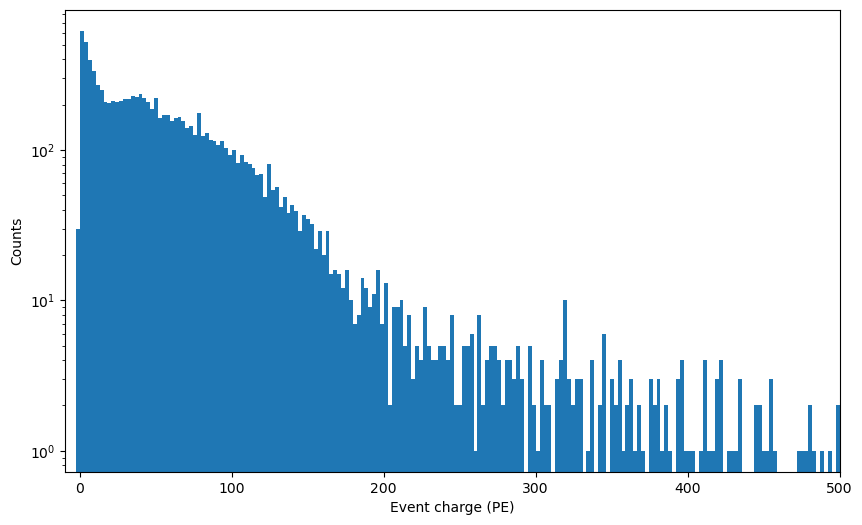

In [ ]:
# Sum entire events pulses that have 2 channels
coinc_event_sums = []
for ev in results:
    pulses = ev["pulses"] if ev["pulses"] else []

    event_sum = 0.0
    for p in pulses:
        if p["two_channel_pulse"]:
            event_sum += p["sum"]

    coinc_event_sums.append(event_sum)
coinc_event_sums = np.array(coinc_event_sums)

plt.figure(figsize=(10, 6))
bins = np.linspace(-10, 500, 200)
plt.hist(coinc_event_sums, bins=bins)
plt.yscale("log")
plt.xlabel("Event charge (PE)")
plt.ylabel("Counts")
plt.xlim(bins.min(), bins.max())
plt.show()

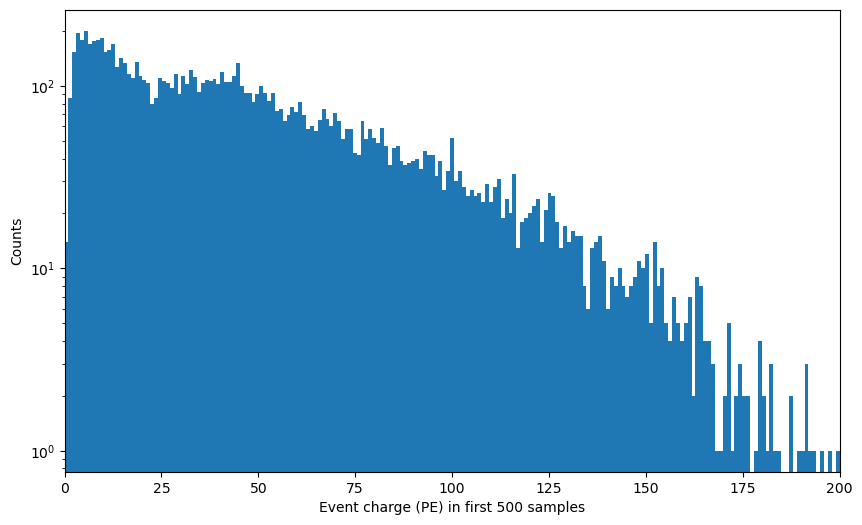

In [ ]:
# Sum just the first 500 samples of each event, on the summed waveform
summed_event_500 = []
for i in range(len(data)):
    summed_wf = data["wfs"][i, 0, :] + data["wfs"][i, 1, :]
    event_sum_500 = np.sum(summed_wf[:500])
    summed_event_500.append(event_sum_500)
summed_event_500 = np.array(summed_event_500)

plt.figure(figsize=(10, 6))
bins = np.linspace(0, 200, 200)
plt.hist(summed_event_500.flatten(), bins=bins)
plt.yscale("log")
plt.xlabel("Event charge (PE) in first 500 samples")
plt.ylabel("Counts")
plt.xlim(bins.min(), bins.max())
plt.show()

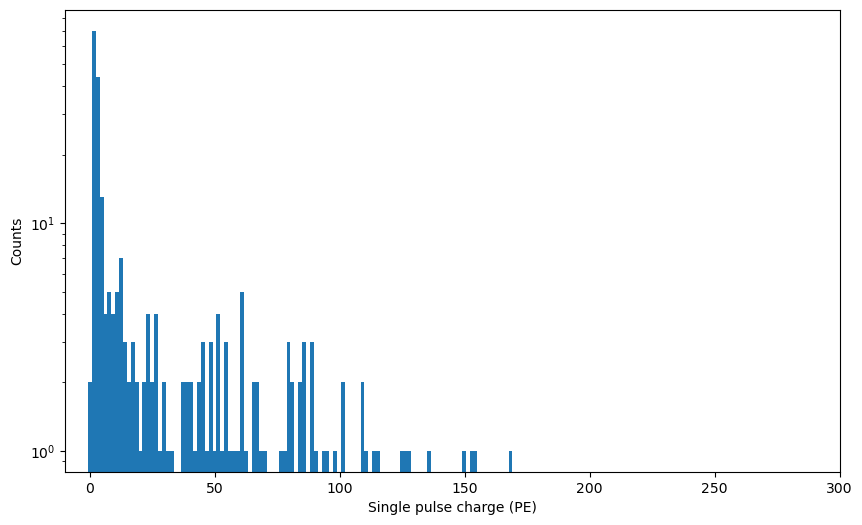

In [ ]:
# Find events with a single pulse and sum those pulses
single_pulse_sums = []
for ev in results:
    pulses = ev["pulses"] if ev["pulses"] else None

    if pulses is not None and len(pulses) == 1:
        single_pulse_sums.append(pulses[0]["sum"])
single_pulse_sums = np.array(single_pulse_sums)

plt.figure(figsize=(10, 6))
bins = np.linspace(-10, 300, 200)
plt.hist(single_pulse_sums, bins=bins)
plt.yscale("log")
plt.xlabel("Single pulse charge (PE)")
plt.ylabel("Counts")
plt.xlim(bins.min(), bins.max())
plt.show()